In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.MaxPool2d(2),          # 32 → 16
    nn.PReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.MaxPool2d(2),          # 16 → 8
    nn.PReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 120, 3, padding=1, groups=60),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 3, padding=1, groups=120),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.MaxPool2d(2),          # 8 → 4
    nn.PReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(120, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.MaxPool2d(2),          # 4 → 2
    nn.PReLU(),

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model11_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model11_0)
describe(model11_0)

MACs: 7.64 MMac, Params: 48.51 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Loading checkpoint from model_weights/model11_0.pt
Starting
Epoch 1/60: Train loss = 1.1577, Train accuracy = 0.5941, Test loss = 1.0915, Test accuracy = 0.6186
Epoch 2/60: Train loss = 0.9304, Train accuracy = 0.6707, Test loss = 0.9202, Test accuracy = 0.6745
Epoch 3/60: Train loss = 0.8671, Train accuracy = 0.7083, Test loss = 0.8768, Test accuracy = 0.7059
Epoch 4/60: Train loss = 0.7424, Train accuracy = 0.7364, Test loss = 0.7494, Test accuracy = 0.7381
Epoch 5/60: Train loss = 0.6680, Train accuracy = 0.7706, Test loss = 0.6892, Test accuracy = 0.7650
Epoch 6/60: Train loss = 0.6877, Train accuracy = 0.7658, Test loss = 0.7128, Test accuracy = 0.7591
Epoch 7/60: Train loss = 0.6535, Train accuracy = 0.7740, Test loss = 0.7050, Test accuracy = 0.7569
Epoch 8/60: Train loss = 0.5815, Train accuracy = 0.7984, Test loss = 0.6151, Test accuracy = 0.7833
Epoch 9/60: Train loss = 0.5796, Train accuracy = 0.7990, Test loss = 0.6168, Test accuracy = 0.7868
Epoch 10/60: Train loss = 0.562

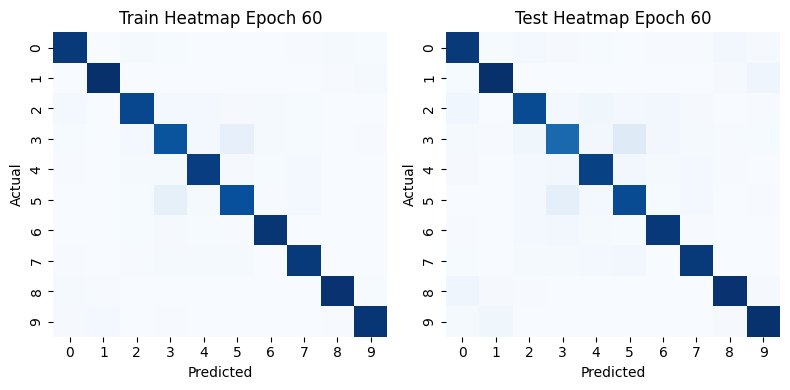

<Figure size 1200x600 with 0 Axes>

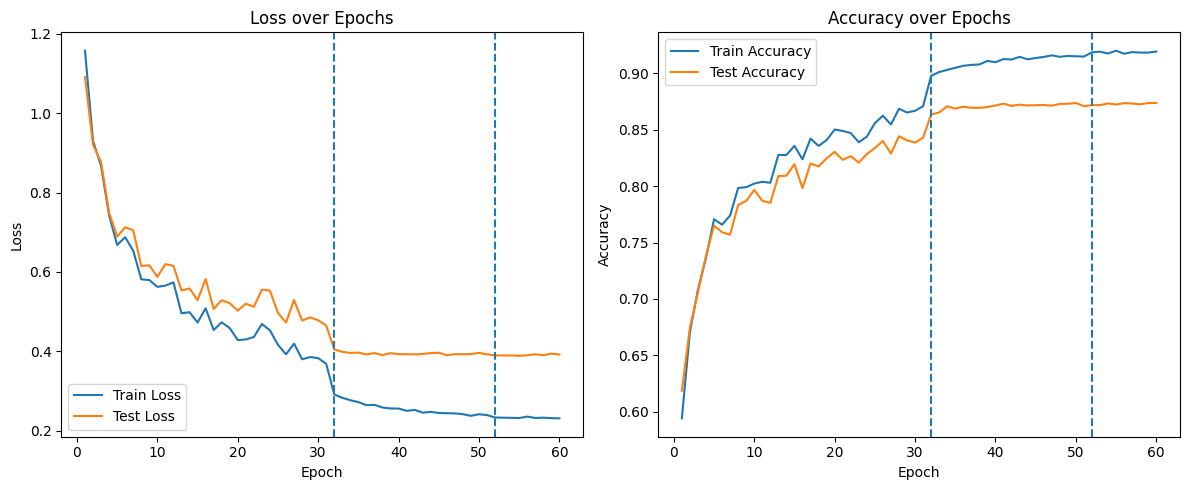

In [6]:
trainf32(model11_0,"model_weights/model11_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model11_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model11_1)
describe(model11_1)

MACs: 7.64 MMac, Params: 48.51 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Starting


/home/saptak/.local/lib/python3.14/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1/60: Train loss = 0.9787, Train accuracy = 0.6527, Test loss = 0.9411, Test accuracy = 0.6608
Epoch 2/60: Train loss = 0.8519, Train accuracy = 0.7031, Test loss = 0.8479, Test accuracy = 0.7107
Epoch 3/60: Train loss = 0.7206, Train accuracy = 0.7476, Test loss = 0.7608, Test accuracy = 0.7405
Epoch 4/60: Train loss = 0.7252, Train accuracy = 0.7513, Test loss = 0.7479, Test accuracy = 0.7520
Epoch 5/60: Train loss = 0.6280, Train accuracy = 0.7808, Test loss = 0.6424, Test accuracy = 0.7798
Epoch 6/60: Train loss = 0.5961, Train accuracy = 0.7942, Test loss = 0.6297, Test accuracy = 0.7887
Epoch 7/60: Train loss = 0.5996, Train accuracy = 0.7901, Test loss = 0.6429, Test accuracy = 0.7837
Epoch 8/60: Train loss = 0.5701, Train accuracy = 0.8031, Test loss = 0.6052, Test accuracy = 0.7969
Epoch 9/60: Train loss = 0.5151, Train accuracy = 0.8209, Test loss = 0.5509, Test accuracy = 0.8118
Epoch 10/60: Train loss = 0.5232, Train accuracy = 0.8168, Test loss = 0.5481, Test accurac

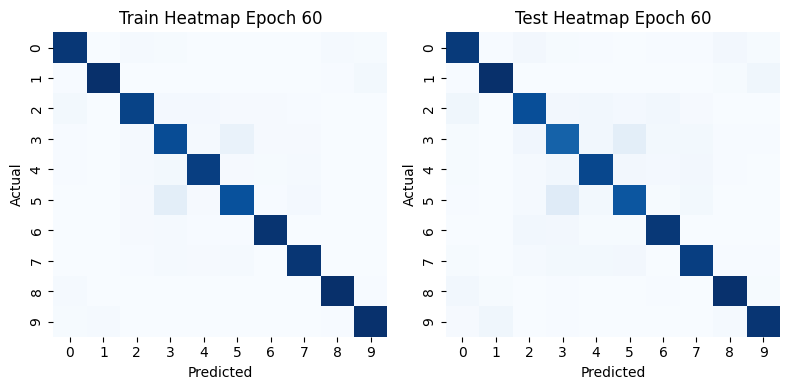

<Figure size 1200x600 with 0 Axes>

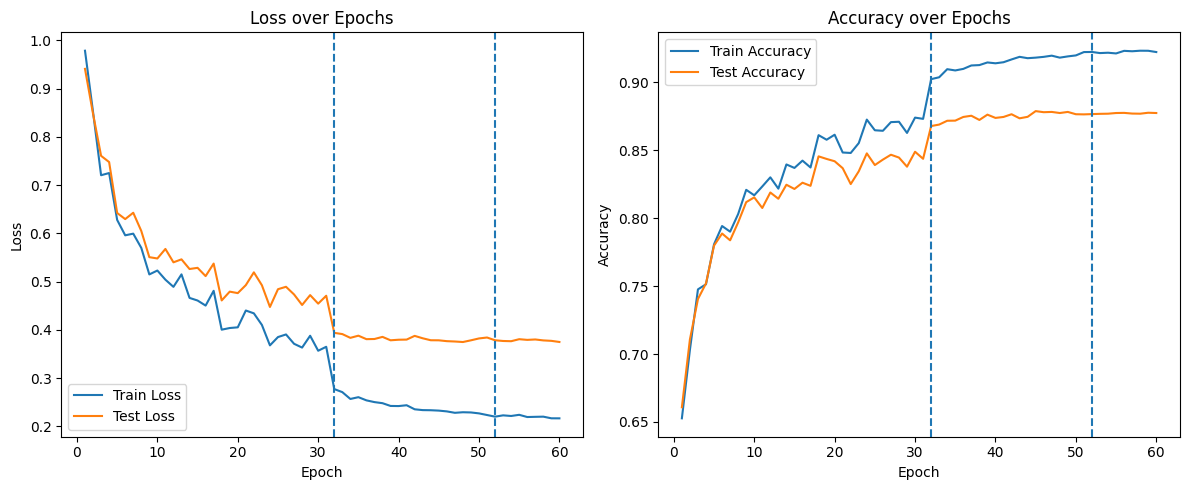

In [8]:
trainf32(model11_1,"model_weights/model11_1.pt",criterion,train_dataset,val_dataset, batch_size=64)